# 01. Filtering (Gambar Standar)


<table>
  <tr>
    <td>Nama</td>
    <td>Steven Tjhia</td>
  </tr>
  <tr>
    <td>NIM</td>
    <td>13522103</td>
  </tr>
  <tr>
    <td>Fitur Unik</td>
    <td>
      <p>
        1. Penambahan noise salt & pepper pada raw image untuk median filter
        <br>
        2. Penggunaan kernel Disk untuk Median Filter
      </p>
    </td>
  </tr>
</table>

## 1.1 Inisiasi

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage import data, io, filters, img_as_float, img_as_ubyte
from skimage.morphology import disk
from skimage.util import random_noise

In [2]:
output_dir = 'output'

## 1.2 Utility Functions

In [3]:
def display_comparison(raw, filtered, filter_name, params_str, img_name):
    fig, axes = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
    ax = axes.ravel()

    ax[0].imshow(raw, cmap=plt.cm.gray)
    ax[0].set_title(f'Raw ({img_name})')
    ax[0].axis('off')

    ax[1].imshow(filtered, cmap=plt.cm.gray)
    ax[1].set_title(f'{filter_name} Filter\n{params_str}')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

## 1.3 Experiments

### 1.3.1 Load Images

In [4]:
print("--- Loading Images ---")
try:
    camera = img_as_float(data.camera())
    coins = img_as_float(data.coins())
    checkerboard_img = img_as_float(data.checkerboard())

    images = {
        'camera': camera,
        'coins': coins,
        'checkerboard': checkerboard_img
    }
    print("Images loaded successfully.")

except Exception as e:
    print(f"Error loading images: {e}")
    images = {}
    
print("\n--- Saving Original Images ---")
for name, img in images.items():
    raw_output_filename = os.path.join("raw", f'raw_{name}.png')
    try:
        io.imsave(raw_output_filename, img_as_ubyte(img))
        print(f"Saved original image to: {raw_output_filename}")
    except Exception as e:
        print(f"Error saving original image {raw_output_filename}: {e}")

--- Loading Images ---
Images loaded successfully.

--- Saving Original Images ---
Saved original image to: raw\raw_camera.png
Saved original image to: raw\raw_coins.png
Saved original image to: raw\raw_checkerboard.png


### 1.3.2 Gaussian Filter

Params

<table>
    <tr>
        <td>Sigma (stdev)</td>
        <td>3.0</td>
    </tr>
</table>


--- Applying Gaussian Filter ---
Parameters: sigma=3.0

Processing camera...
Saved Gaussian filtered image to: output\gaussian_output_camera.png


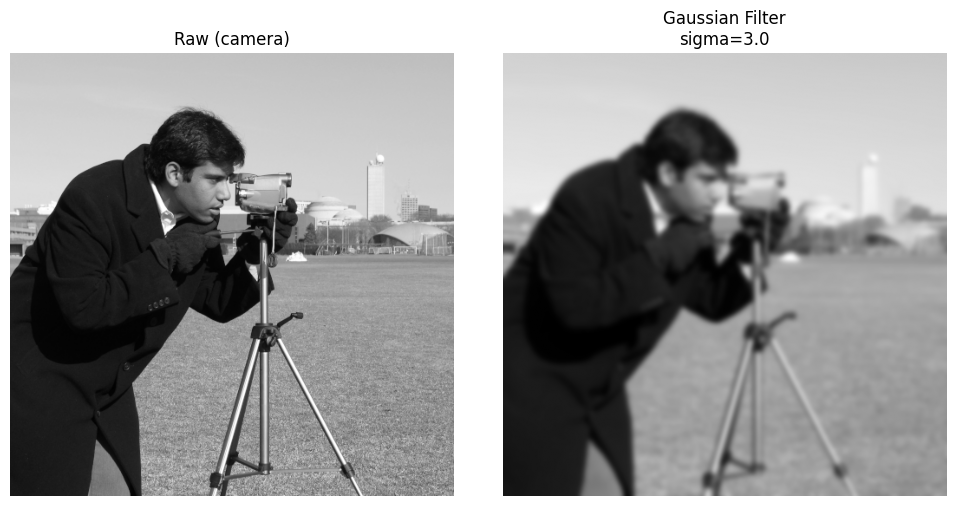


Processing coins...
Saved Gaussian filtered image to: output\gaussian_output_coins.png


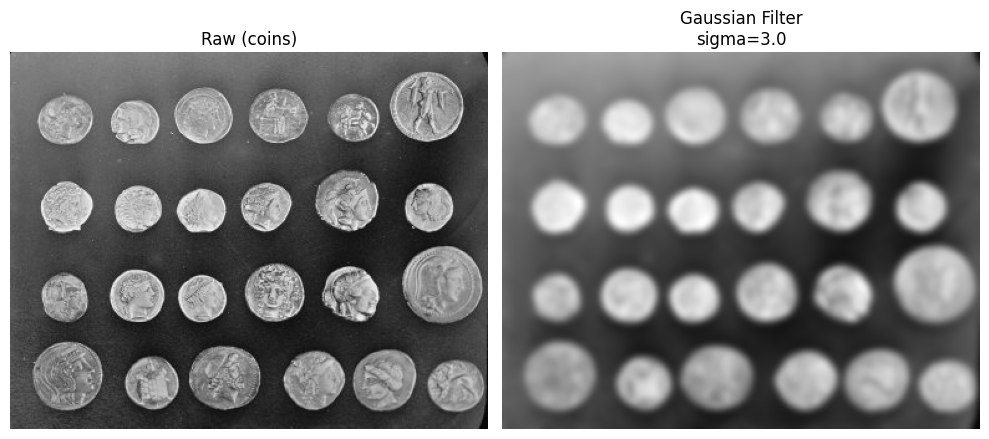


Processing checkerboard...
Saved Gaussian filtered image to: output\gaussian_output_checkerboard.png


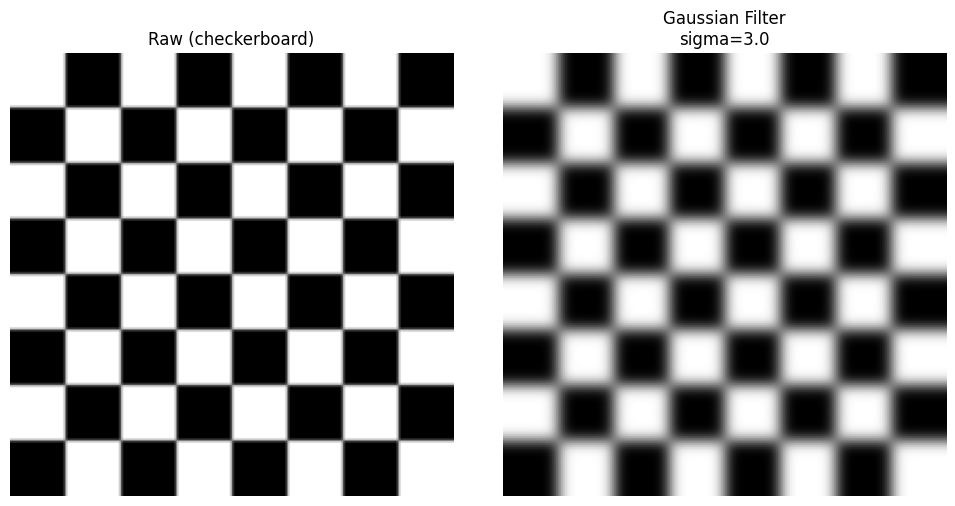

In [5]:
gaussian_sigma = 3.0
gaussian_params_str = f'sigma={gaussian_sigma}'
print("\n--- Applying Gaussian Filter ---")
print(f"Parameters: {gaussian_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    gaussian_filtered = filters.gaussian(img, sigma=gaussian_sigma, channel_axis=None)
    output_filename = os.path.join(output_dir, f'gaussian_output_{name}.png')
    try:
        io.imsave(output_filename, img_as_ubyte(gaussian_filtered))
        print(f"Saved Gaussian filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, gaussian_filtered, 'Gaussian', gaussian_params_str, name)

Params

<table>
    <tr>
        <td>Sigma (stdev)</td>
        <td>6.0</td>
    </tr>
</table>


--- Applying Gaussian Filter ---
Parameters: sigma=6.0

Processing camera...
Saved Gaussian filtered image to: output\gaussian_output_camera_sigma_6.png


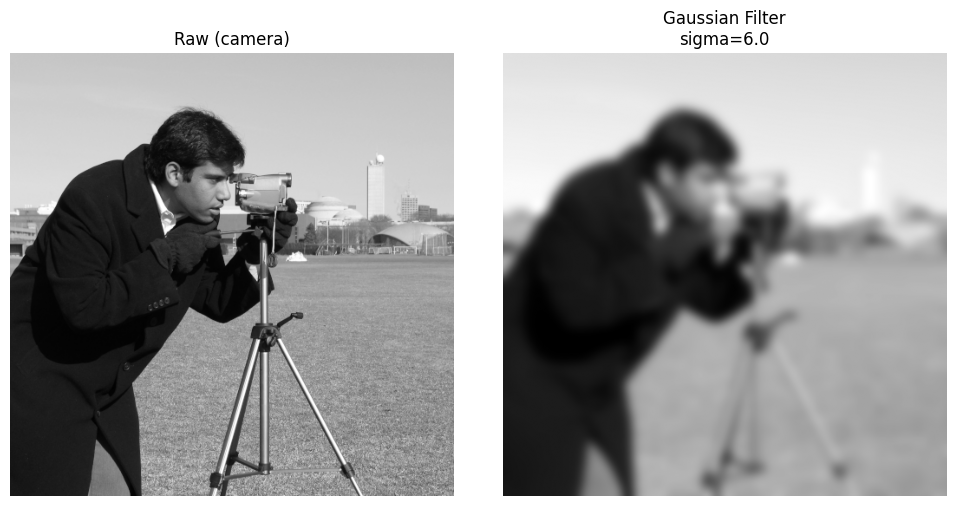


Processing coins...
Saved Gaussian filtered image to: output\gaussian_output_coins_sigma_6.png


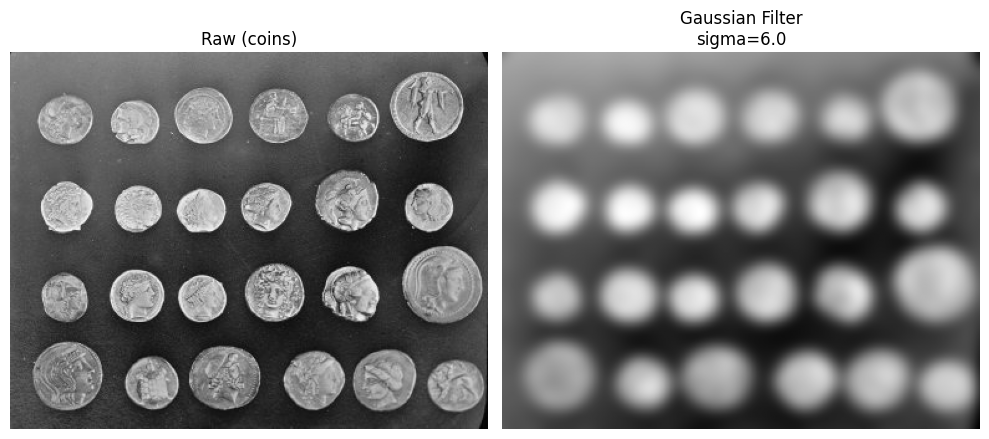


Processing checkerboard...
Saved Gaussian filtered image to: output\gaussian_output_checkerboard_sigma_6.png


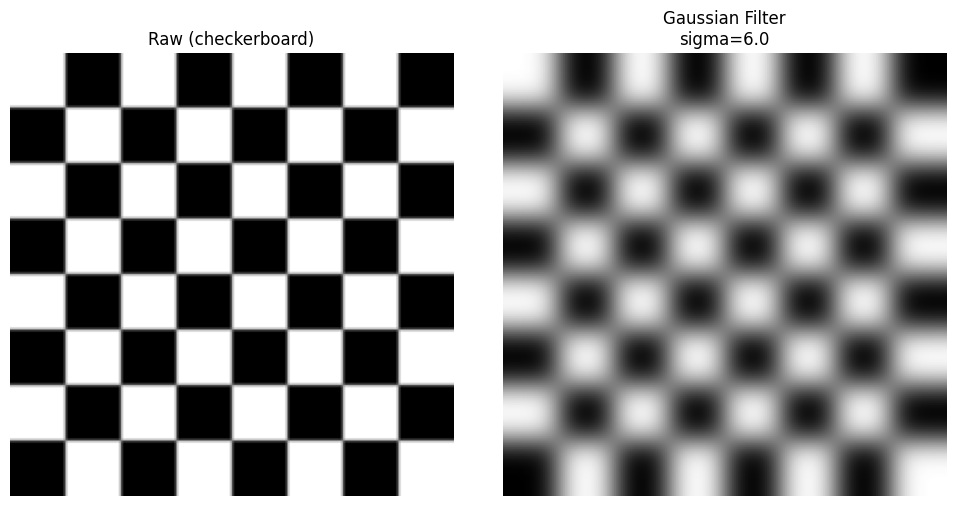

In [6]:
gaussian_sigma = 6.0
gaussian_params_str = f'sigma={gaussian_sigma}'
print("\n--- Applying Gaussian Filter ---")
print(f"Parameters: {gaussian_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    gaussian_filtered = filters.gaussian(img, sigma=gaussian_sigma, channel_axis=None)
    output_filename = os.path.join(output_dir, f'gaussian_output_{name}_sigma_6.png')
    try:
        io.imsave(output_filename, img_as_ubyte(gaussian_filtered))
        print(f"Saved Gaussian filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, gaussian_filtered, 'Gaussian', gaussian_params_str, name)

### 1.3.3 Median Filter

Params

<table>
    <tr>
        <td>Kernel Shape</td>
        <td>Disk</td>
    </tr>
    <tr>
        <td>Kernel Radius</td>
        <td>2</td>
    </tr>
</table>


--- Applying Median Filter ---
Parameters: disk radius=2

Processing camera...
Saved noisy image to: noisy_salt_and_pepper\salt_and_pepper_camera.png
Saved Median filtered image to: output\median_output_camera.png


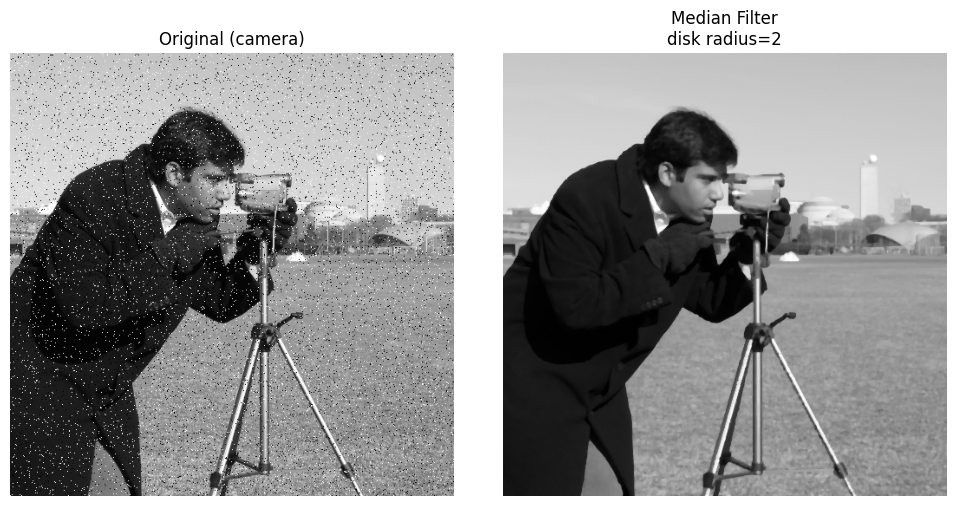


Processing coins...
Saved noisy image to: noisy_salt_and_pepper\salt_and_pepper_coins.png
Saved Median filtered image to: output\median_output_coins.png


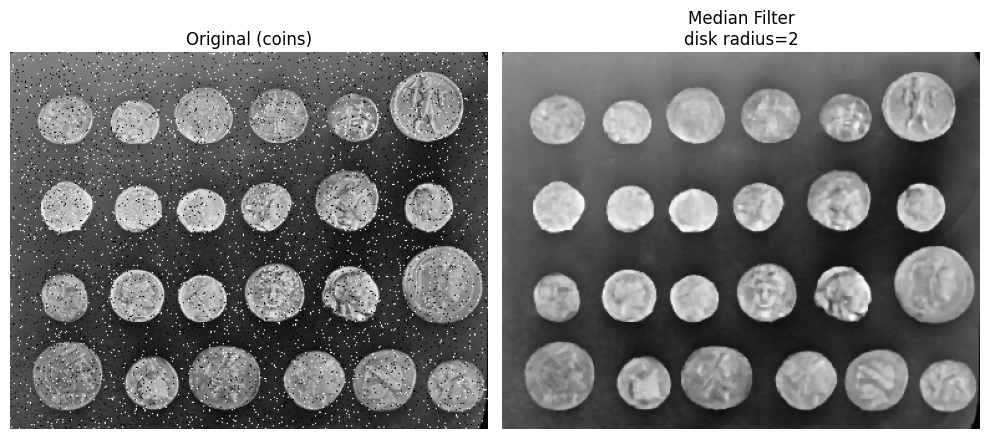


Processing checkerboard...
Saved noisy image to: noisy_salt_and_pepper\salt_and_pepper_checkerboard.png
Saved Median filtered image to: output\median_output_checkerboard.png


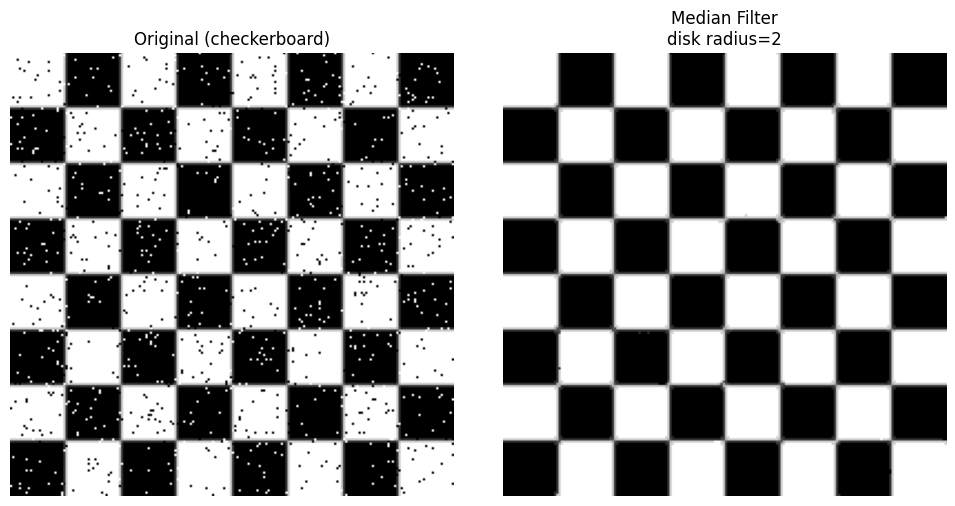

In [8]:
median_radius = 2
noise_amount = 0.05 # Amount of salt & pepper noise
footprint = disk(median_radius)
median_params_str = f'disk radius={median_radius}'
print("\n--- Applying Median Filter ---")
print(f"Parameters: {median_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    
    # Add salt and pepper noise
    noisy_img = random_noise(img, mode='s&p', amount=noise_amount)
    noisy_img = np.clip(noisy_img, 0.0, 1.0)

    noisy_output_filename = os.path.join("noisy_salt_and_pepper", f'salt_and_pepper_{name}.png')
    try:
        io.imsave(noisy_output_filename, img_as_ubyte(noisy_img))
        print(f"Saved noisy image to: {noisy_output_filename}")
    except Exception as e:
        print(f"Error saving noisy image {noisy_output_filename}: {e}")
    
    img_to_filter = noisy_img
    
    median_filtered_ubyte = filters.median(img_as_ubyte(img_to_filter), footprint=footprint)
    median_filtered = img_as_float(median_filtered_ubyte)
    output_filename = os.path.join(output_dir, f'median_output_{name}.png')
    try:
        io.imsave(output_filename, median_filtered_ubyte)
        print(f"Saved Median filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img_to_filter, median_filtered, 'Median', median_params_str, name)

Params

<table>
    <tr>
        <td>Kernel Shape</td>
        <td>Disk</td>
    </tr>
    <tr>
        <td>Kernel Radius</td>
        <td>5</td>
    </tr>
</table>


--- Applying Median Filter ---
Parameters: disk radius=5

Processing camera...
Saved noisy image to: noisy_salt_and_pepper\salt_and_pepper_camera.png
Saved Median filtered image to: output\median_output_camera_radius_5.png


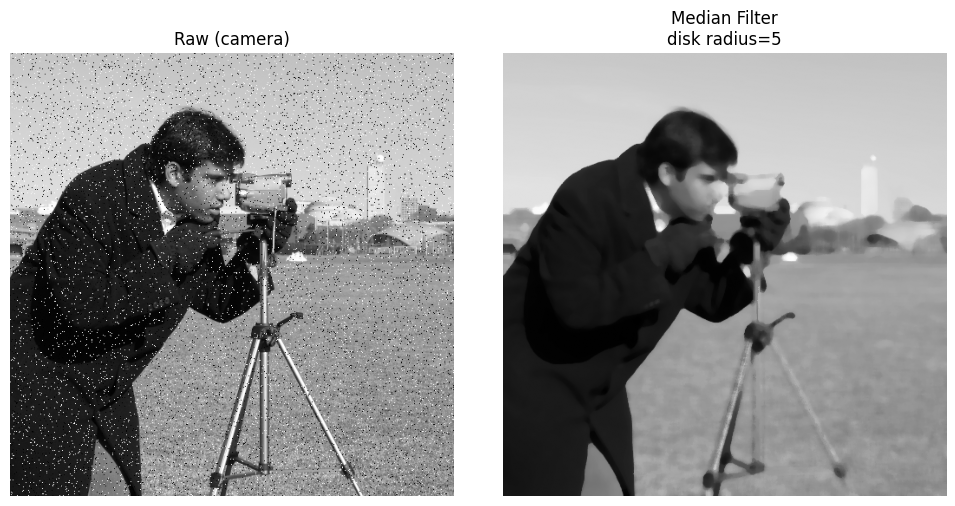


Processing coins...
Saved noisy image to: noisy_salt_and_pepper\salt_and_pepper_coins.png
Saved Median filtered image to: output\median_output_coins_radius_5.png


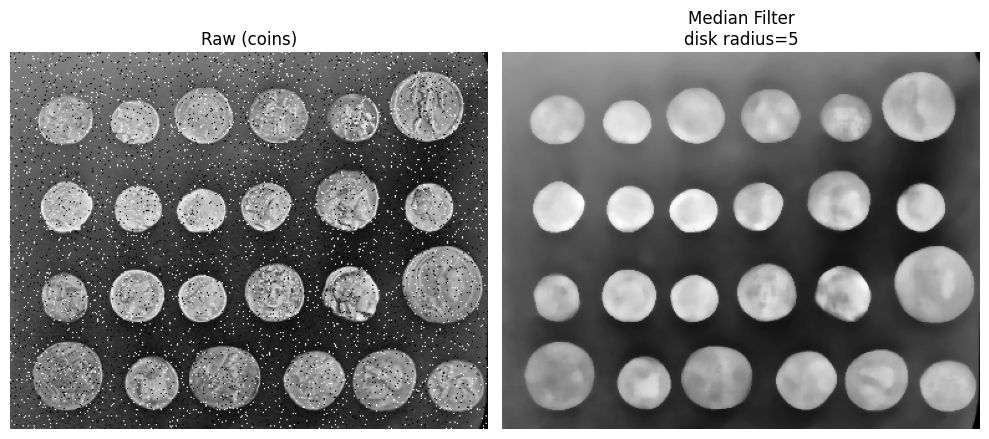


Processing checkerboard...
Saved noisy image to: noisy_salt_and_pepper\salt_and_pepper_checkerboard.png
Saved Median filtered image to: output\median_output_checkerboard_radius_5.png


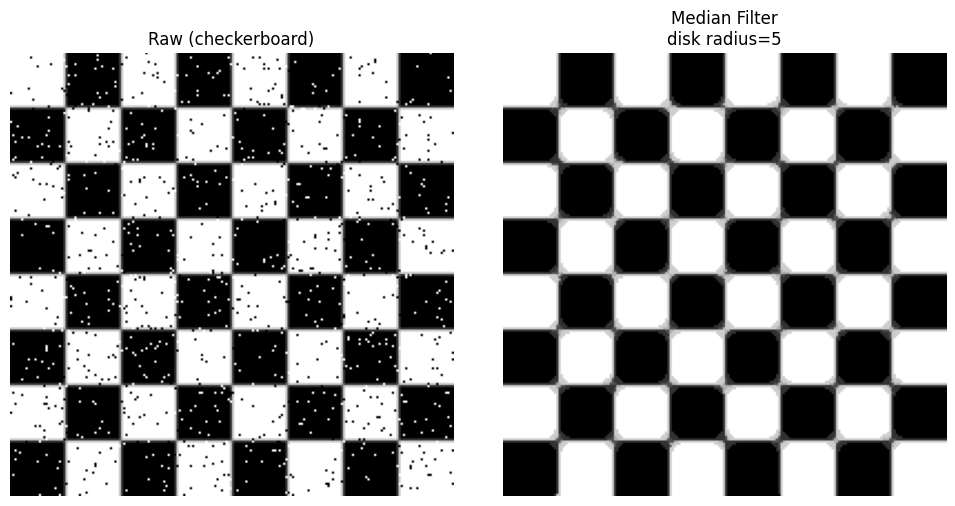

In [7]:
median_radius = 5
noise_amount = 0.05 # Amount of salt & pepper noise
footprint = disk(median_radius)
median_params_str = f'disk radius={median_radius}'
print("\n--- Applying Median Filter ---")
print(f"Parameters: {median_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    
    # Add salt and pepper noise
    noisy_img = random_noise(img, mode='s&p', amount=noise_amount)
    noisy_img = np.clip(noisy_img, 0.0, 1.0)

    noisy_output_filename = os.path.join("noisy_salt_and_pepper", f'salt_and_pepper_{name}.png')
    try:
        io.imsave(noisy_output_filename, img_as_ubyte(noisy_img))
        print(f"Saved noisy image to: {noisy_output_filename}")
    except Exception as e:
        print(f"Error saving noisy image {noisy_output_filename}: {e}")
    
    img_to_filter = noisy_img
    
    median_filtered_ubyte = filters.median(img_as_ubyte(img_to_filter), footprint=footprint)
    median_filtered = img_as_float(median_filtered_ubyte)
    output_filename = os.path.join(output_dir, f'median_output_{name}_radius_5.png')
    try:
        io.imsave(output_filename, median_filtered_ubyte)
        print(f"Saved Median filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img_to_filter, median_filtered, 'Median', median_params_str, name)

### 1.3.4 Sobel Filter

#### 1.3.4.1 Sobel Filter (Horizontal)


--- Applying Sobel Filter ---
Parameters: Standard 3x3 Kernels

Processing camera...
Saved Sobel filtered image to: output\sobel_h_output_camera.png


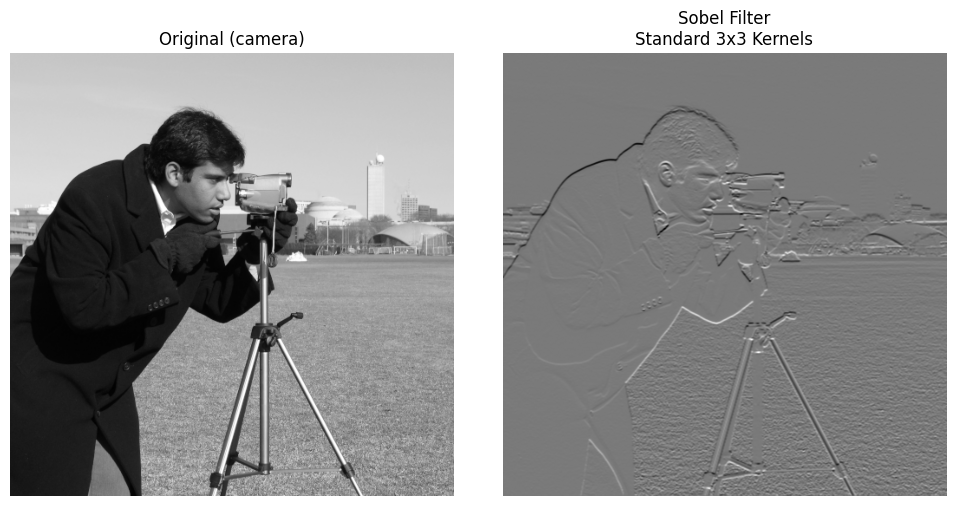


Processing coins...
Saved Sobel filtered image to: output\sobel_h_output_coins.png


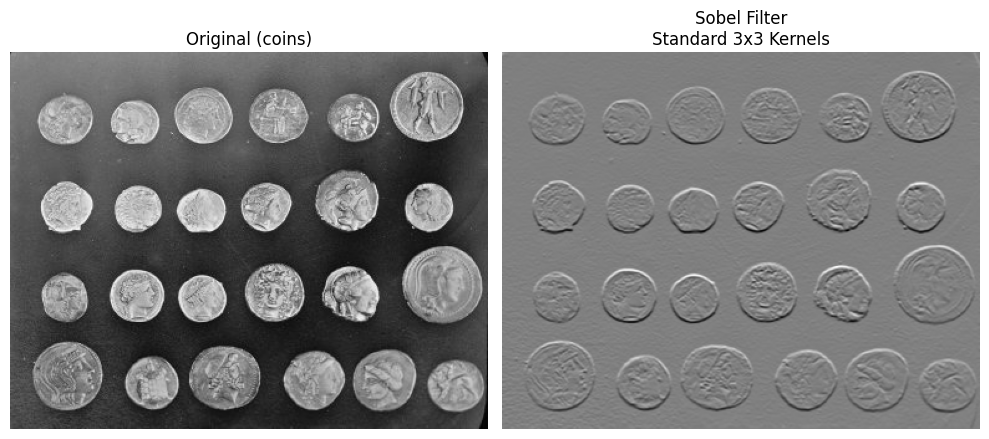


Processing checkerboard...
Saved Sobel filtered image to: output\sobel_h_output_checkerboard.png


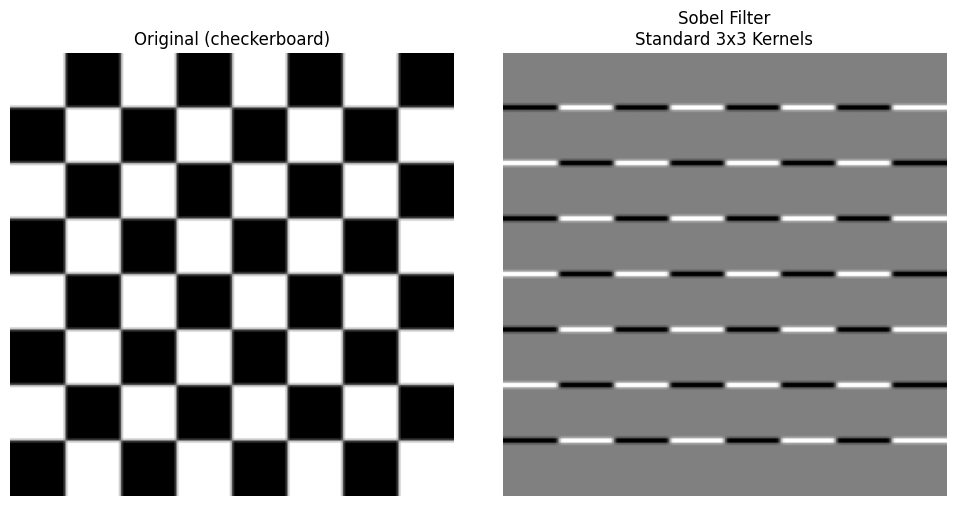


--- Filtering complete. ---


In [24]:
sobel_params_str = 'Standard 3x3 Kernels'
print("\n--- Applying Sobel Filter ---")
print(f"Parameters: {sobel_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    edge_sobel = filters.sobel_h(img)
    output_filename = os.path.join(output_dir, f'sobel_h_output_{name}.png')
    try:
        # Normalize edge map for saving as ubyte
        if np.max(edge_sobel) > np.min(edge_sobel): # Avoid division by zero if image is flat
                edge_sobel_ubyte = img_as_ubyte((edge_sobel - np.min(edge_sobel)) / (np.max(edge_sobel) - np.min(edge_sobel)))
        else:
                edge_sobel_ubyte = img_as_ubyte(edge_sobel) # Image is flat, save as is (all zeros)

        io.imsave(output_filename, edge_sobel_ubyte)
        print(f"Saved Sobel filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_sobel, 'Sobel', sobel_params_str, name)

print("\n--- Filtering complete. ---")


#### 1.3.4.2 Sobel Filter (Vertikal)


--- Applying Sobel Filter ---
Parameters: Standard 3x3 Kernels

Processing camera...
Saved Sobel filtered image to: output\sobel_v_output_camera.png


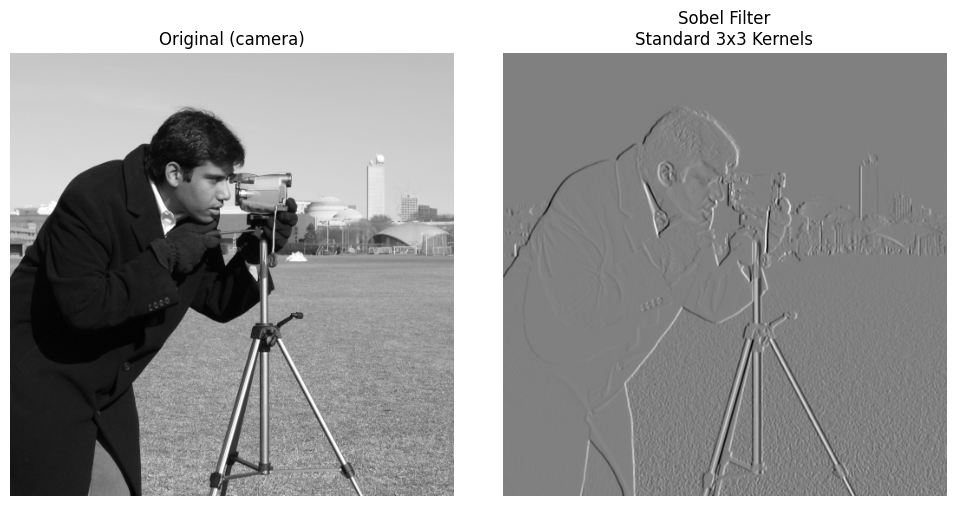


Processing coins...
Saved Sobel filtered image to: output\sobel_v_output_coins.png


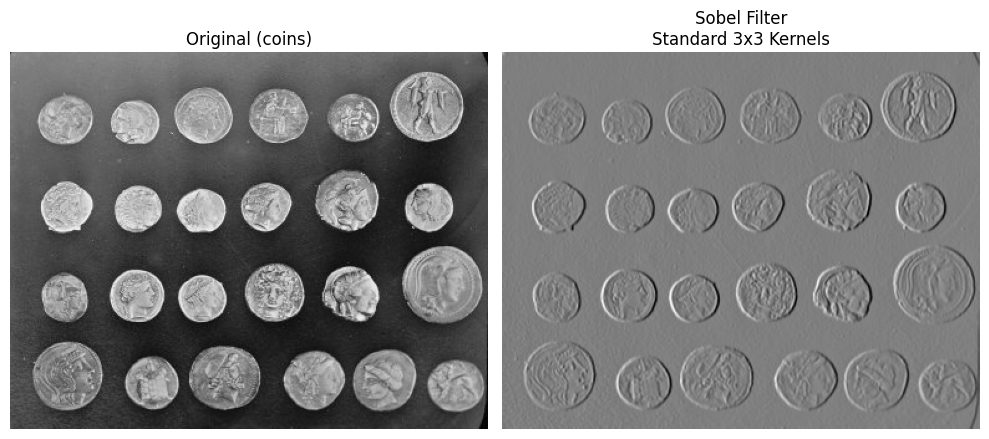


Processing checkerboard...
Saved Sobel filtered image to: output\sobel_v_output_checkerboard.png


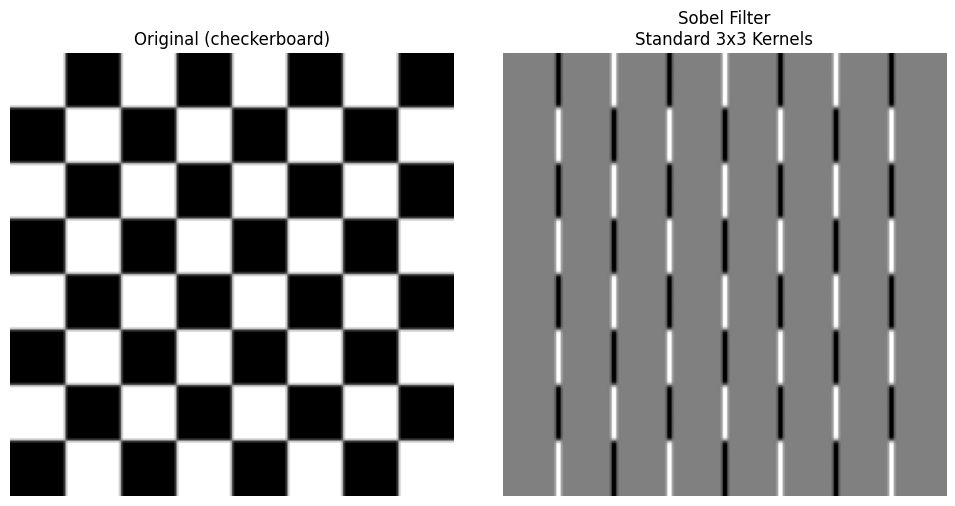


--- Filtering complete. ---


In [23]:
sobel_params_str = 'Standard 3x3 Kernels'
print("\n--- Applying Sobel Filter ---")
print(f"Parameters: {sobel_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    edge_sobel = filters.sobel_v(img)
    output_filename = os.path.join(output_dir, f'sobel_v_output_{name}.png')
    try:
        # Normalize edge map for saving as ubyte
        if np.max(edge_sobel) > np.min(edge_sobel): # Avoid division by zero if image is flat
                edge_sobel_ubyte = img_as_ubyte((edge_sobel - np.min(edge_sobel)) / (np.max(edge_sobel) - np.min(edge_sobel)))
        else:
                edge_sobel_ubyte = img_as_ubyte(edge_sobel) # Image is flat, save as is (all zeros)

        io.imsave(output_filename, edge_sobel_ubyte)
        print(f"Saved Sobel filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_sobel, 'Sobel', sobel_params_str, name)

print("\n--- Filtering complete. ---")


#### 1.3.4.3 Sobel Filter (Horizontal + Vertikal)


--- Applying Sobel Filter ---
Parameters: Standard 3x3 Kernels

Processing camera...
Saved Sobel filtered image to: output\sobel_output_camera.png


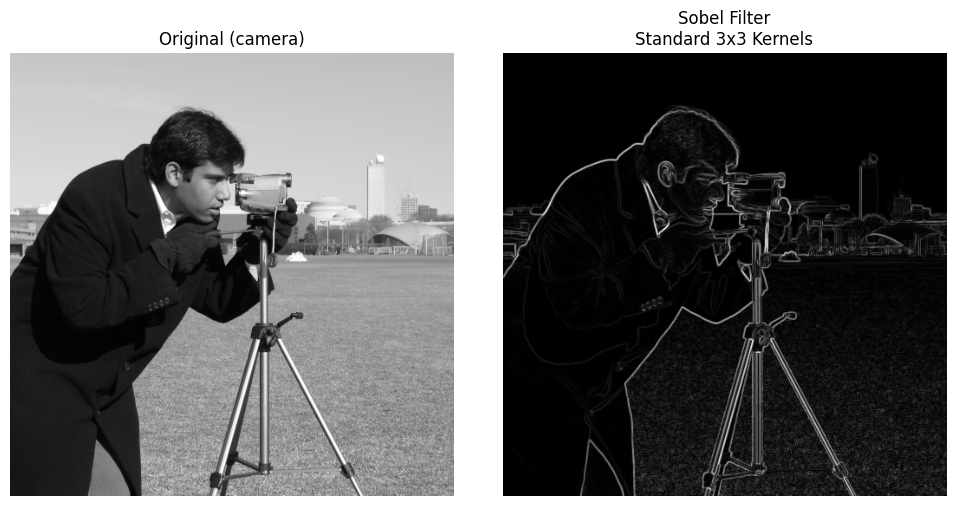


Processing coins...
Saved Sobel filtered image to: output\sobel_output_coins.png


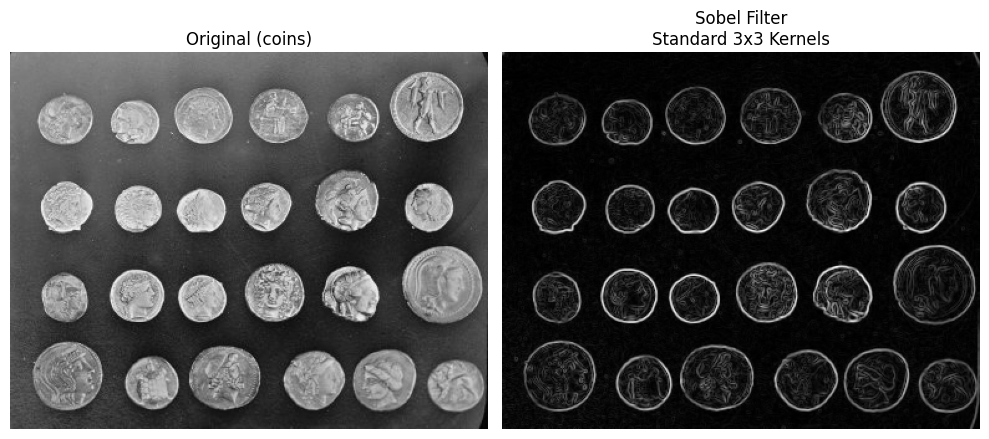


Processing checkerboard...
Saved Sobel filtered image to: output\sobel_output_checkerboard.png


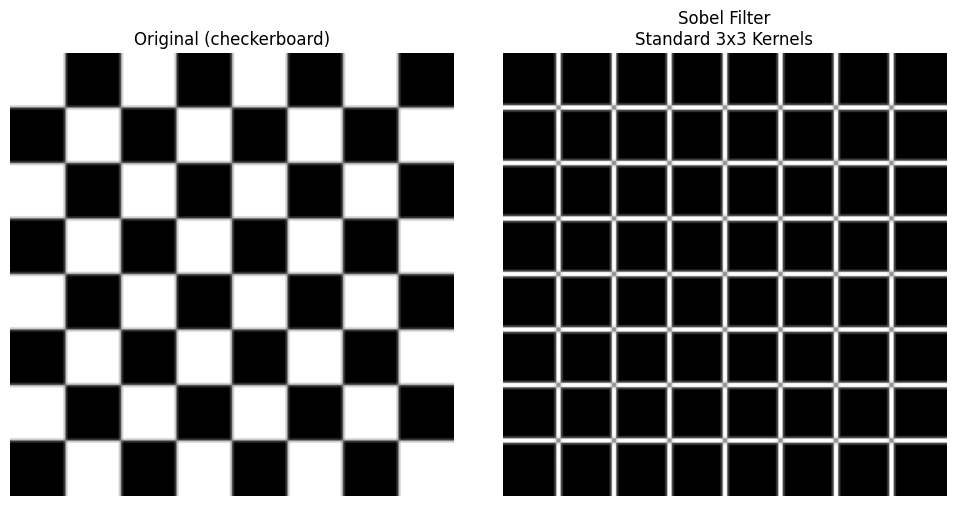


--- Filtering complete. ---


In [22]:
sobel_params_str = 'Standard 3x3 Kernels'
print("\n--- Applying Sobel Filter ---")
print(f"Parameters: {sobel_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    edge_sobel = filters.sobel(img) # Horizontal + Vertikal
    output_filename = os.path.join(output_dir, f'sobel_output_{name}.png')
    try:
        # Normalize edge map for saving as ubyte
        if np.max(edge_sobel) > np.min(edge_sobel): # Avoid division by zero if image is flat
                edge_sobel_ubyte = img_as_ubyte((edge_sobel - np.min(edge_sobel)) / (np.max(edge_sobel) - np.min(edge_sobel)))
        else:
                edge_sobel_ubyte = img_as_ubyte(edge_sobel) # Image is flat, save as is (all zeros)

        io.imsave(output_filename, edge_sobel_ubyte)
        print(f"Saved Sobel filtered image to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_sobel, 'Sobel', sobel_params_str, name)

print("\n--- Filtering complete. ---")
